kNN



In [ ]:
from sklearn.preprocessing import StandardScaler
#from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
#from cuml.model_selection import train_test_split
#from cuml.metrics import mean_absolute_error, r2_score, mean_squared_error
from cuml.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
import hashlib

In [ ]:
from google.colab import drive
# 1. Collega Drive
drive.mount('/content/drive')

# 2. Vai nella cartella dove hai i file e la cartella audio
%cd "/content/drive/MyDrive/Magistrale/Tesi/Fase2"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Magistrale/Tesi/Fase2


In [ ]:
NORMALIZED_AUDIO=False
normalized_str="[NORMALIZED_AUDIO]" * NORMALIZED_AUDIO

CSV_INPUT_PATH = f"{normalized_str}audio_dataset.csv"
LABEL_COLUMN="portata"
RESULTS_CSV_PATH=f"{normalized_str}Results_randomized_search_knn_cuml.csv"

In [ ]:
# 1. CARICAMENTO DATI
# Assumiamo che il file CSV abbia la colonna identificativa come prima colonna
df = pd.read_csv(CSV_INPUT_PATH, index_col=0)

In [ ]:
# Calcoliamo la matrice di correlazione
correlazione = df.corr()

# Soglia minima di correlazione (puoi alzarla o abbassarla, es. 0.1)
soglia_minima = 0.1

# Selezioniamo la correlazione rispetto al target (in valore assoluto)
corr_con_target = correlazione['portata'].abs()

# Teniamo solo le feature che superano la soglia (incluso il target stesso!)
feature_da_tenere = corr_con_target[corr_con_target >= soglia_minima].index
df_filtrato = df[feature_da_tenere]

print(f"Feature rimosse perché poco correlate con il target: {set(df.columns) - set(df_filtrato.columns)}")

Feature rimosse perché poco correlate con il target: {'mel_b127_iqr', 'mel_b7_std', 'mel_b43_min', 'mel_b13_min', 'mel_b77_q1', 'mel_b122_max', 'mel_b126_q1', 'mel_b44_min', 'mel_b53_min', 'mel_b26_min', 'mel_b31_min', 'mel_b125_q1', 'ber_median', 'mel_b111_min', 'mel_b86_min', 'mel_b127_median', 'mel_b7_max', 'mel_b9_std', 'mel_b77_min', 'mel_b19_max', 'mel_b8_max', 'mel_b21_max', 'mel_b15_max', 'mel_b52_q1', 'mel_b41_min', 'mel_b65_min', 'mel_b38_min', 'sc_mean', 'mel_b87_min', 'mel_b16_max', 'mel_b37_min', 'mel_b42_min', 'sc_delta_mean', 'mel_b79_max', 'mel_b102_delta_mean', 'mel_b17_min', 'mel_b22_max', 'mel_b18_max', 'mel_b1_iqr', 'mel_b54_min', 'mel_b47_min', 'mel_b32_min', 'mel_b110_min', 'mel_b76_q1', 'mel_b20_max', 'mel_b4_min', 'mel_b95_min', 'mel_b50_min', 'mel_b48_min', 'mel_b101_min', 'mel_b125_min', 'zcr_q1', 'mel_b35_min', 'mel_b126_iqr', 'mel_b109_min', 'mel_b66_min', 'mel_b18_std', 'mel_b0_max', 'mel_b97_min', 'mel_b64_min', 'mel_b59_min', 'mel_b2_max', 'mel_b44_max', 

In [ ]:
# Isoliamo le feature filtrate dal punto precedente (escludendo il target)
X_corrente = df_filtrato.drop(columns=['portata'])
matrice_corr_X = X_corrente.corr().abs()

# Creiamo una maschera booleana per guardare solo il triangolo superiore della matrice
# (Evita di controllare due volte la stessa coppia di variabili o la diagonale)
maschera = np.triu(np.ones(matrice_corr_X.shape), k=1).astype(bool)
triangolo_superiore = matrice_corr_X.where(maschera)

# Soglia massima di correlazione (oltre questa, le feature sono troppo simili)
soglia_massima = 0.85

# Troviamo i nomi delle colonne che superano la soglia
colonne_da_eliminare = [colonna for colonna in triangolo_superiore.columns if any(triangolo_superiore[colonna] > soglia_massima)]

# Creiamo il DataFrame finale pronto per lo split
df = df_filtrato.drop(columns=colonne_da_eliminare)

print(f"Feature rimosse per alta multicollinearità: {colonne_da_eliminare}")

Feature rimosse per alta multicollinearità: ['ae_q3', 'ae_delta_mean', 'rms_std', 'rms_max', 'rms_median', 'rms_iqr', 'zcr_std', 'zcr_max', 'zcr_median', 'zcr_q3', 'zcr_iqr', 'ber_std', 'ber_max', 'ber_iqr', 'sc_std', 'sc_max', 'sc_q3', 'sc_iqr', 'bw_min', 'bw_q1', 'bw_median', 'bw_iqr', 'mel_b0_mean', 'mel_b0_std', 'mel_b0_q1', 'mel_b0_median', 'mel_b0_q3', 'mel_b0_iqr', 'mel_b1_mean', 'mel_b1_q1', 'mel_b1_median', 'mel_b1_q3', 'mel_b2_mean', 'mel_b2_std', 'mel_b2_min', 'mel_b2_q1', 'mel_b2_median', 'mel_b2_q3', 'mel_b3_mean', 'mel_b3_std', 'mel_b3_q1', 'mel_b3_median', 'mel_b3_q3', 'mel_b3_iqr', 'mel_b4_mean', 'mel_b4_std', 'mel_b4_q1', 'mel_b4_median', 'mel_b4_q3', 'mel_b4_iqr', 'mel_b5_mean', 'mel_b5_std', 'mel_b5_q1', 'mel_b5_median', 'mel_b5_q3', 'mel_b5_iqr', 'mel_b6_mean', 'mel_b6_std', 'mel_b6_q1', 'mel_b6_median', 'mel_b6_q3', 'mel_b6_iqr', 'mel_b7_mean', 'mel_b7_q1', 'mel_b7_median', 'mel_b7_q3', 'mel_b7_iqr', 'mel_b8_mean', 'mel_b8_min', 'mel_b8_q1', 'mel_b8_median', 'mel_b

In [ ]:
# 2. PREPARAZIONE X e y
target_column = 'portata'
X = df.drop(columns=[target_column])
y = df[target_column]

# 3. SPLIT TRAIN/TEST
# Dividiamo i dati: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
train_indices = df.index.get_indexer(X_train.index).tolist()
test_indices = df.index.get_indexer(X_test.index).tolist()
print("SHA256 Train set: "+hashlib.sha256(str(train_indices).encode('utf-8')).hexdigest())
print("SHA256 Test set: "+hashlib.sha256(str(test_indices).encode('utf-8')).hexdigest())

SHA256 Train set: 3381aba560824a2b713b8724342d48ed8c45d7149b2859d1179308acd2bb3eda
SHA256 Test set: 37c8cd28d3b0a03d8da427cce8eb628a87b11df1871f655016b5aeafc3993235


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

OTTIMIZZAZIONE IPERPARAMETRI

In [ ]:
# Definizione del modello cuML (GPU)
# Nota: cuML gestisce la memoria GPU internamente
knn_to_optimize = KNeighborsRegressor()

# Griglia di parametri per l'audio
param_distributions = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],  # Numeri dispari per evitare pareggi
    'weights': ['uniform', 'distance'],    # 'distance' pesa di più i vicini più simili
    'p': [1, 2]                            # 1: Manhattan, 2: Euclidea
}

randomized_search = RandomizedSearchCV(
    estimator=knn_to_optimize,
    param_distributions=param_distributions,
    n_iter=200,                             # Prova 20 combinazioni casuali
    cv=3,                                  # Cross-validation a 3 fold
    scoring='neg_mean_absolute_error',
    refit=False,
    verbose=2,
    random_state=42
)

# Avvio della ricerca
randomized_search.fit(X_train, y_train)
print("Randomized Search completato")

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=200. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=   0.4s
[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=   0.0s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=   0.0s
[CV] END ................n_neighbors=3, p=2, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=3, p=2, weights=uniform; total time=   0.0s
[CV] END ................n_neighbors=3, p=2, weights=uniform; total time=   0.0s
[CV] END ...............n_neighbors=3, p=2, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=3, p=2, weights=distance; total time=   0.0s
[CV] END ...............n_neighbors=3, p=2, weights=distance; total time=   0.0s
[CV] END ................n_n

In [ ]:
# Risultati
print("Migliori parametri individuati:")
print(randomized_search.best_params_)

Migliori parametri individuati:
{'weights': 'distance', 'p': 1, 'n_neighbors': 5}


In [ ]:
results = pd.DataFrame(randomized_search.cv_results_)
results = results.sort_values(by="rank_test_score", ascending=True)
results.to_csv(RESULTS_CSV_PATH, index=False)


DEFINIZIONE DEL MODELLO FINALE

In [ ]:
best_params = randomized_search.best_params_
knn_regressor = KNeighborsRegressor(**best_params)

# 4. Addestramento finale sul set completo
knn_regressor.fit(X_train, y_train)
print("Addestramento finale completato")

Addestramento finale completato


VALUTAZIONE DEL MODELLO FINALE

In [ ]:
# 3. PREDIZIONE E VALUTAZIONE
y_pred = knn_regressor.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- PERFORMANCE KNN ---")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.4f}")

--- PERFORMANCE KNN ---
R^2 Score: 0.6074
MAE: 68.2053
MAPE: 19.79%
RMSE: 94.3598


In [ ]:
# Calcoliamo l'importanza (richiede qualche secondo perché deve fare dei test)
# n_repeats indica quante volte mescolare ogni feature (5 è un buon valore)
results = permutation_importance(
    knn_regressor, X_train, y_train,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=42
)

# Creazione della Series per la visualizzazione
# X è il tuo DataFrame originale con i nomi delle colonne
importances = pd.Series(results.importances_mean, index=X.columns)

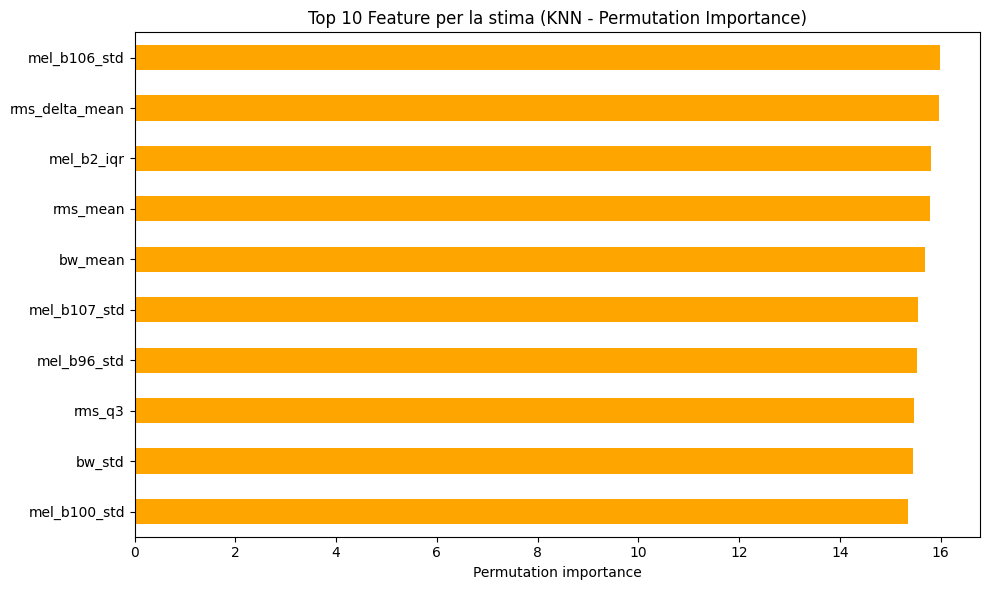

In [ ]:
plt.figure(figsize=(10, 6))

# Prendiamo le 10 più importanti e ordiniamole
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='orange')

plt.title("Top 10 Feature per la stima (KNN - Permutation Importance)")
plt.xlabel("Permutation importance")
plt.tight_layout()
plt.show()